<a href="https://colab.research.google.com/github/YOGITHA20/Customer_Marketing_Analysis/blob/main/Customer_Marketing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
url = "https://raw.githubusercontent.com/nqtquoctrung94/RFM_Customer_Personality_Analysis/main/marketing_campaign.csv"

df = pd.read_csv(url, sep="\t")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [2]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [5]:
df["Year_Birth"].value_counts().sort_index().head(10)

,count
Year_Birth,
1893,1
1899,1
1900,1
1940,1
1941,1
1943,7
1944,7
1945,8
1946,16


In [6]:
df[df["Year_Birth"] == 1893]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
239,11004,1893,2n Cycle,Single,60182.0,0,1,17-05-2014,23,8,...,4,0,0,0,0,0,0,3,11,0


In [7]:
df[df["Income"] == 666666]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,6,0,0,0,0,0,0,3,11,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["ID"].nunique()

2240

In [10]:
df["Age"] = 2014 - df["Year_Birth"]

In [11]:
df["Age"].describe()

,Age
count,2240.000000
mean,45.194196
std,11.984069
min,18.000000
25%,37.000000
50%,44.000000
75%,55.000000
max,121.000000


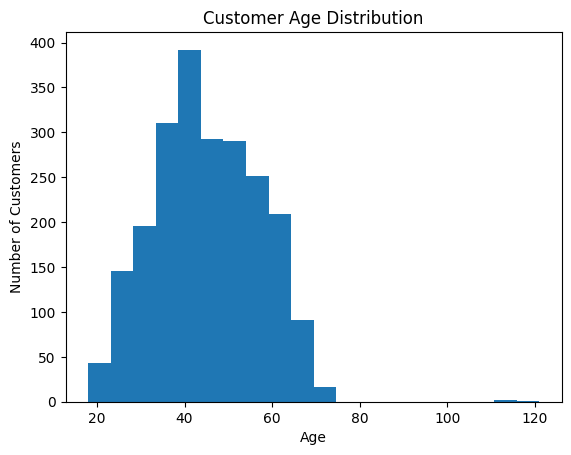

In [12]:
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")
plt.show()

In [13]:
df[df["Age"] > 100][["ID", "Year_Birth", "Age"]]

,ID,Year_Birth,Age
192,7829,1900,114
239,11004,1893,121
339,1150,1899,115


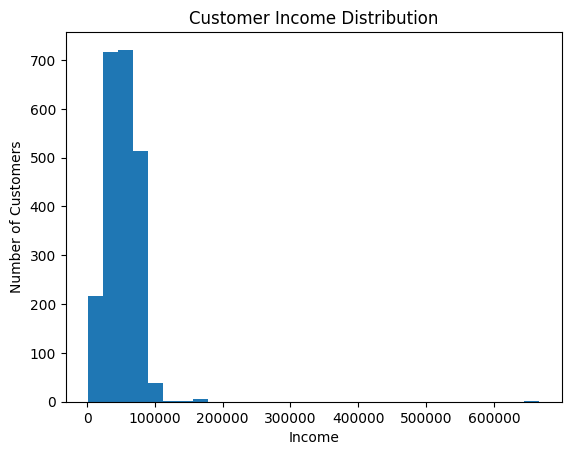

In [14]:
plt.hist(df["Income"].dropna(), bins=30)
plt.xlabel("Income")
plt.ylabel("Number of Customers")
plt.title("Customer Income Distribution")
plt.show()

In [15]:
df[df["Income"] == 666666]

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age
2233,9432,1977,Graduation,Together,666666.0,1,0,02-06-2013,23,9,...,0,0,0,0,0,0,3,11,0,37


In [16]:
df["Income"].mean()

np.float64(52247.25135379061)

In [17]:
df[df["Income"] != 666666]["Income"].mean()

np.float64(51969.861399548536)

In [18]:
df[df["Income"].isnull()][
    ["ID", "Education", "Marital_Status", "Age", "Kidhome", "Teenhome"]
]


,ID,Education,Marital_Status,Age,Kidhome,Teenhome
10,1994,Graduation,Married,31,1,0
27,5255,Graduation,Single,28,1,0
43,7281,PhD,Single,55,0,0
48,7244,Graduation,Single,63,2,1
58,8557,Graduation,Single,32,1,0
71,10629,2n Cycle,Married,41,1,0
90,8996,PhD,Married,57,2,1
91,9235,Graduation,Single,57,1,1
92,5798,Master,Together,41,0,0
128,8268,PhD,Married,53,0,1


In [19]:
df["Income_Clean"] = df["Income"].replace(666666, np.nan)

In [20]:
df["Income_Clean"].isnull().sum()

np.int64(25)

In [21]:
# Convert date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

# Create Age directly from Year_Birth
df["Age_Clean"] = 2014 - df["Year_Birth"]

# Remove unrealistic ages
df.loc[df["Age_Clean"] > 100, "Age_Clean"] = np.nan

# Remove constant columns
df = df.drop(columns=["Z_CostContact", "Z_Revenue"])

# Check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [22]:
df["Total_Spending"] = (
    df["MntWines"] +
    df["MntFruits"] +
    df["MntMeatProducts"] +
    df["MntFishProducts"] +
    df["MntSweetProducts"] +
    df["MntGoldProds"]
)

In [23]:
df["Total_Spending"].describe()

,Total_Spending
count,2240.000000
mean,605.798214
std,602.249288
min,5.000000
25%,68.750000
50%,396.000000
75%,1045.500000
max,2525.000000


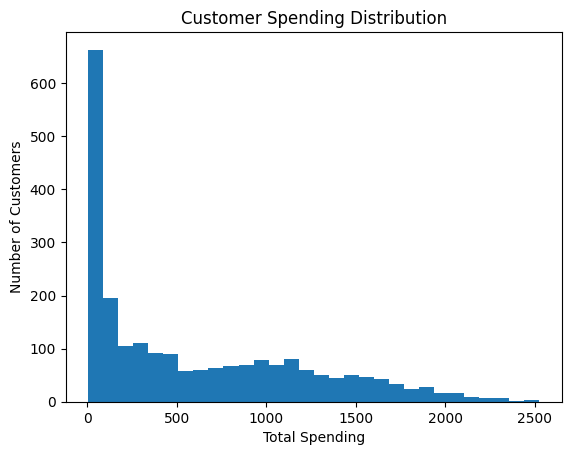

In [24]:
plt.hist(df["Total_Spending"], bins=30)
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.title("Customer Spending Distribution")
plt.show()

In [25]:
df["Spending_Segment"] = pd.cut(
    df["Total_Spending"],
    bins=[0, 500, 1000, 1500, 3000],
    labels=["Low", "Medium", "High", "Very High"]
)

In [26]:
df["Spending_Segment"].value_counts().sort_index()

,count
Spending_Segment,
Low,1246
Medium,392
High,356
Very High,246


In [27]:
df[["Income_Clean", "Total_Spending"]].corr()

,Income_Clean,Total_Spending
Income_Clean,1.00000,0.79265
Total_Spending,0.79265,1.00000


In [28]:
df.groupby("Spending_Segment")["Response"].mean().sort_values(ascending=False)

/tmp/ipykernel_40044/2448691093.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Spending_Segment")["Response"].mean().sort_values(ascending=False)


,Response
Spending_Segment,
Very High,0.418699
High,0.191011
Medium,0.102041
Low,0.098716


In [29]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

campaign_response = df[campaign_cols].mean() * 100

campaign_response

,0
AcceptedCmp1,6.428571
AcceptedCmp2,1.339286
AcceptedCmp3,7.276786
AcceptedCmp4,7.455357
AcceptedCmp5,7.276786
Response,14.910714


In [30]:
df.groupby("Education")["Response"].mean() * 100

,Response
Education,
2n Cycle,10.837438
Basic,3.703704
Graduation,13.487134
Master,15.405405
PhD,20.781893


In [31]:
channel_totals = df[
    ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
].sum()

channel_totals

,0
NumWebPurchases,9150
NumCatalogPurchases,5963
NumStorePurchases,12970


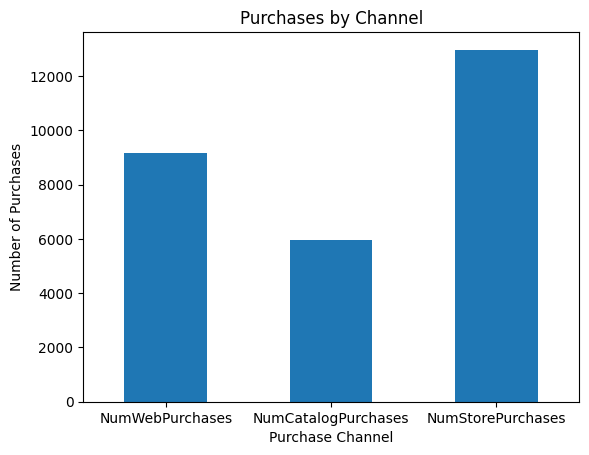

In [32]:
channel_totals.plot(kind="bar")

plt.xlabel("Purchase Channel")
plt.ylabel("Number of Purchases")
plt.title("Purchases by Channel")
plt.xticks(rotation=0)
plt.show()

In [33]:
df.groupby("Spending_Segment")[
    ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
].mean()

/tmp/ipykernel_40044/2826844897.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Spending_Segment")[


,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Spending_Segment,,,
Low,2.653291,0.765650,3.656501
Medium,6.285714,3.752551,8.331633
High,5.814607,5.455056,8.834270
Very High,5.325203,6.487805,8.142276


In [34]:
df.groupby("Response")[
    ["NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases"]
].mean()

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Response,,,
0,3.911857,2.391920,5.736621
1,5.071856,4.203593,6.095808


In [35]:
df.groupby("Response")["Recency"].mean()

,Recency
Response,
0,51.514690
1,35.383234


In [36]:
df.groupby("Response")["NumDealsPurchases"].mean()

,NumDealsPurchases
Response,
0,2.323190
1,2.335329


In [37]:
df.groupby("Response")["NumWebVisitsMonth"].mean()

,NumWebVisitsMonth
Response,
0,5.320567
1,5.293413


In [38]:
df.groupby("Response")[
    ["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3",
     "AcceptedCmp4", "AcceptedCmp5"]
].mean() * 100

,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5
Response,,,,,
0,3.410283,0.524659,4.512067,5.508919,3.725079
1,23.652695,5.988024,23.053892,18.562874,27.544910
